## Import Supporting Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')
from ultralytics import YOLO
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torchvision.models as models
from torchvision.models import AlexNet_Weights, GoogLeNet_Weights
import tensorflow as tf
from tensorflow.keras.models import Model
from PIL import Image
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from tkinter.filedialog import askopenfilename
from torchvision import transforms
from tensorflow.keras.preprocessing.image import load_img,img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input as prp2
from matplotlib import pyplot as plt
%matplotlib inline

## Loading Detector, Feature Extractor and our Trained Model

In [2]:
from sklearn import preprocessing
scaler = preprocessing.MinMaxScaler()
model = YOLO("best.pt")
FM = pd.read_csv('AlexNet_FM.csv')

# Load the pre-trained Alexnet model
alexnet = torch.hub.load('pytorch/vision:v0.10.0', 'alexnet', weights=AlexNet_Weights.IMAGENET1K_V1)
alexnet.eval()

transform1 = transforms.Compose([transforms.Resize(256),    transforms.CenterCrop(224),   transforms.ToTensor(),  transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
rmodel =OneVsRestClassifier(SVC(kernel="rbf")).fit(scaler.fit_transform(FM.iloc[:,:-3].values), FM.iloc[:,-2].values)  

Using cache found in C:\Users\SUMANTH N/.cache\torch\hub\pytorch_vision_v0.10.0


## Defined Relavent Funtions

In [3]:
def Classify(path):
    input_image = Image.open(path)
    input_tensor = transform1(input_image)
    input_batch = input_tensor.unsqueeze(0)
    return rmodel.predict(scaler.transform(alexnet(input_batch).detach().numpy()))[0]
    
def segment(Im,Rm):
    temp = Im.copy()
    for j in range(temp.shape[2]):
        temp[:,:,j] = temp[:,:,j]*Rm[:,:,j]
    return temp
    
def predict(impt):
    results = model([impt],verbose=False) 
    bbx = []
    pre = []
    for r in results:
        img = np.copy(r.orig_img)
        mms=[]
        for c in r:
            b_mask = np.zeros(img.shape[:2], np.uint8)
            contour = c.masks.xy.pop().astype(np.int32).reshape(-1, 1, 2)
            _ = cv2.drawContours(b_mask, [contour], -1, (255, 255, 255), cv2.FILLED)
            mask3ch = cv2.cvtColor(b_mask, cv2.COLOR_GRAY2BGR)
            mms.append(mask3ch//np.max(mask3ch))
            isolated = segment(r.orig_img,mask3ch//np.max(mask3ch))
            x1, y1, x2, y2 = c.boxes.xyxy.cpu().numpy().squeeze().astype(np.int32)
            bbx.append([x1, y1, x2, y2])
            cv2.imwrite('crop.jpg',isolated[y1:y2, x1:x2])
            pre.append(Classify('crop.jpg'))
            
        if len(mms)>1:
            a = mms[0]
            for m in mms[1:]:
                a +=m
            sg = segment(r.orig_img,a)
        elif len(mms)==1:
            a = mms[0]
            sg = segment(r.orig_img,a)
        else:
            return bbx, img, img, pre
    print(pre)
    return bbx, img, sg, pre

def Plotting(bbx,img,seg,pred,title):
    # Plotting
    fig = plt.figure(figsize=(18, 12),facecolor='blue')
    rows = 1
    columns = 4
    #plt.title("Cattle Age Prediction")
    IM=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    fig.add_subplot(rows, columns, 1)
    plt.imshow(IM)
    plt.axis('off')
    plt.title("Input Image")

    for e in bbx:
        cv2.rectangle(IM, (e[0], e[1]), (e[2], e[3]), (0, 255,0),5)
    fig.add_subplot(rows, columns, 2)
    plt.imshow(IM)
    plt.axis('off')
    plt.title("RoI Detection")
    
    fig.add_subplot(rows, columns, 3)
    plt.imshow(cv2.cvtColor(seg, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("RoI Segmentation")

    for e,tx in zip(bbx,pred):
        cv2.putText(IM,tx.upper(), (e[0], e[1]-15), cv2.FONT_HERSHEY_SIMPLEX, 4, (255,0,0), 4)
    fig.add_subplot(rows, columns, 4)
    plt.imshow(IM)
    plt.axis('off')
    plt.title(title)
    plt.get_current_fig_manager().set_window_title(title)
    plt.show()

## Main Function Calling

['grade1']


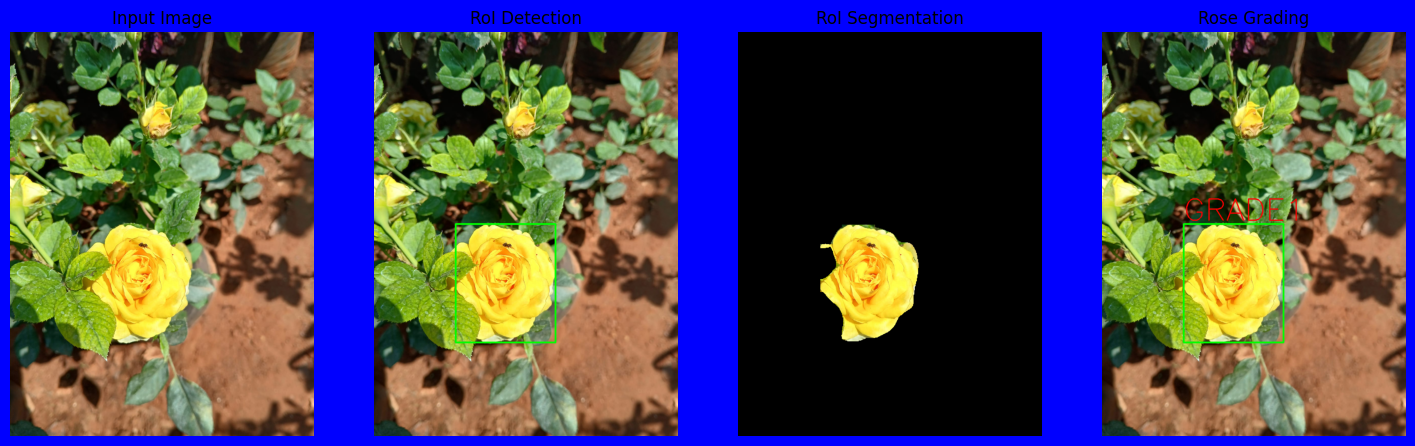

In [4]:
title='Rose Grading'
a, b, c, d = predict(askopenfilename())
Plotting(a, b, c, d,title)